In [10]:
# ═══════════════════════════════════════════════════════
# CELL 1 — Setup, paths, configuration
# ═══════════════════════════════════════════════════════
!pip install -q ultralytics

import os, json, time, random, unicodedata, warnings, pickle, re
from pathlib import Path
from io import BytesIO

import numpy as np
import pandas as pd
import cv2
from PIL import Image
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
from torch.amp import autocast, GradScaler
import editdistance
from transformers import VisionEncoderDecoderModel, TrOCRProcessor
from ultralytics import YOLO
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from tqdm.auto import tqdm

warnings.filterwarnings("ignore")
os.environ["TOKENIZERS_PARALLELISM"] = "false"

random.seed(42); np.random.seed(42); torch.manual_seed(42)
if torch.cuda.is_available():
    torch.cuda.manual_seed_all(42)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {DEVICE}")

ARTIFACTS_PATH   = Path("/kaggle/input/datasets/nehamalik10/phase4-session2-outputs/session2_artifacts.json")
TROCR_BASE_CKPT  = Path("/kaggle/input/models/nehamalik10/trocr-base-2/pytorch/default/1/trocr 2.pt")
YOLO_MODEL_PATH  = Path("/kaggle/input/models/nehamalik10/yolo-detector/pytorch/default/1/yolo_best.pt")  # VERIFY
AKSHAR_DATASET   = Path("/kaggle/input/datasets/nehamalik10/akshar-manual-annotations/akshar_dataset")
LINE_VAL_PATH    = Path("/kaggle/input/datasets/nehamalik10/hindi-page-level-dataset/line_val.parquet")
LINE_TRAIN_PATH  = Path("/kaggle/input/datasets/nehamalik10/hindi-page-level-dataset/line_train.parquet")

OUTPUT_DIR = Path("/kaggle/working/phase4_pagelevel_base")
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

MODEL_NAME = "microsoft/trocr-base-handwritten"
TROCR_SIZE = 384
MAX_LEN    = 48
NO_REPEAT_NGRAM = 0
NUM_BEAMS_PIPELINE = 4

assert YOLO_MODEL_PATH.exists(), f"YOLO model not found at {YOLO_MODEL_PATH}"
assert TROCR_BASE_CKPT.exists(), f"TrOCR checkpoint not found at {TROCR_BASE_CKPT}"
print("Paths verified.")

Device: cuda
Paths verified.


In [11]:
# ═══════════════════════════════════════════════════════
# CELL 2 — Vocabulary
# ═══════════════════════════════════════════════════════
with open(ARTIFACTS_PATH, "r", encoding="utf-8") as f:
    art = json.load(f)

char_to_token = art["char_to_token"]
token_to_char = {int(k): v for k, v in art["token_to_char"].items()}
VOCAB_SIZE = art["VOCAB_SIZE"]
PAD_ID = art["PAD_ID"]; BOS_ID = art["BOS_ID"]; EOS_ID = art["EOS_ID"]; UNK_ID = art["UNK_ID"]

def encode(text):
    text = unicodedata.normalize("NFC", text)
    return [char_to_token.get(c, UNK_ID) for c in text] + [EOS_ID]

def decode_ids(ids):
    out = []
    for tok in ids:
        tok = int(tok)
        if tok == EOS_ID: break
        if tok in (PAD_ID, BOS_ID): continue
        out.append(token_to_char.get(tok, ""))
    return unicodedata.normalize("NFC", "".join(out))

print(f"Vocab loaded: {VOCAB_SIZE} tokens")

Vocab loaded: 140 tokens


In [12]:
# ═══════════════════════════════════════════════════════
# CELL 3 — Load YOLO word detector
# ═══════════════════════════════════════════════════════
yolo_model = YOLO(YOLO_MODEL_PATH)
print(f"YOLO detector loaded from {YOLO_MODEL_PATH}")

YOLO detector loaded from /kaggle/input/models/nehamalik10/yolo-detector/pytorch/default/1/yolo_best.pt


In [13]:
# ═══════════════════════════════════════════════════════
# CELL 4 — Load TrOCR-base (fully fine-tuned, no LoRA)
# ═══════════════════════════════════════════════════════
processor = TrOCRProcessor.from_pretrained(MODEL_NAME)

model = VisionEncoderDecoderModel.from_pretrained(MODEL_NAME)
model.config.pad_token_id = PAD_ID
model.config.decoder_start_token_id = BOS_ID
model.config.eos_token_id = EOS_ID
model.config.bos_token_id = BOS_ID
model.decoder.config.pad_token_id = PAD_ID
model.decoder.config.bos_token_id = BOS_ID
model.decoder.config.eos_token_id = EOS_ID
model.decoder.config.decoder_start_token_id = BOS_ID
model.decoder.resize_token_embeddings(VOCAB_SIZE)

ckpt = torch.load(TROCR_BASE_CKPT, map_location="cpu", weights_only=False)
state_dict = ckpt["model_state_dict"] if isinstance(ckpt, dict) and "model_state_dict" in ckpt else ckpt
missing, unexpected = model.load_state_dict(state_dict, strict=False)
if missing: print(f"WARNING — missing keys: {len(missing)} (first 5: {missing[:5]})")
if unexpected: print(f"WARNING — unexpected keys: {len(unexpected)} (first 5: {unexpected[:5]})")

model = model.to(DEVICE).eval()
total_params = sum(p.numel() for p in model.parameters())
print(f"TrOCR-base loaded. Total params: {total_params:,} (~{total_params/1e6:.0f}M)")
if not missing and not unexpected:
    print("Checkpoint loaded cleanly.")

Loading weights:   0%|          | 0/478 [00:00<?, ?it/s]

VisionEncoderDecoderModel LOAD REPORT from: microsoft/trocr-base-handwritten
Key                         | Status  | 
----------------------------+---------+-
encoder.pooler.dense.bias   | MISSING | 
encoder.pooler.dense.weight | MISSING | 

Notes:
- MISSING	:those params were newly initialized because missing from the checkpoint. Consider training on your downstream task.


TrOCR-base loaded. Total params: 282,593,792 (~283M)
Checkpoint loaded cleanly.


In [14]:
# ═══════════════════════════════════════════════════════
# CELL 5 — Preprocessing functions
# ═══════════════════════════════════════════════════════
def autocontrast(gray, clip=1.0):
    hist = cv2.calcHist([gray],[0],None,[256],[0,256]).flatten()
    c = clip/100*float(gray.size); cs = np.cumsum(hist)
    lo, hi = int(np.searchsorted(cs, c)), int(255 - np.searchsorted(cs[::-1], c))
    if hi <= lo: return gray
    return np.clip((gray.astype(np.float32)-lo)*255/(hi-lo), 0, 255).astype(np.uint8)

def deskew(gray, max_deg=5.0):
    edges = cv2.Canny(gray, 50, 150)
    lines = cv2.HoughLines(edges, 1, np.pi/180, 100)
    if lines is None: return gray
    angle = float(np.median([l[0][1]*180/np.pi - 90 for l in lines]))
    if abs(angle) > max_deg: return gray
    h, w = gray.shape[:2]
    M = cv2.getRotationMatrix2D((w/2, h/2), angle, 1.0)
    return cv2.warpAffine(gray, M, (w, h), borderValue=255)

def preprocess_page(img):
    arr = np.array(img)
    if arr.ndim==3 and arr.shape[2]==4: arr = arr[:,:,:3]
    gray = arr if arr.ndim==2 else cv2.cvtColor(arr, cv2.COLOR_RGB2GRAY)
    return cv2.cvtColor(deskew(autocontrast(gray)), cv2.COLOR_GRAY2RGB)

def preprocess_crop_for_trocr(crop_pil):
    gray = np.array(crop_pil.convert("L"))
    p2, p98 = np.percentile(gray, (2, 98))
    if p98 > p2:
        gray = np.clip((gray - p2) / (p98 - p2) * 255, 0, 255).astype(np.uint8)
    _, bw = cv2.threshold(gray, 0, 255, cv2.THRESH_BINARY_INV + cv2.THRESH_OTSU)
    coords = cv2.findNonZero(bw)
    if coords is not None:
        x, y, w, h = cv2.boundingRect(coords)
        y1, y2 = max(0, y-2), min(gray.shape[0], y+h+2)
        x1, x2 = max(0, x-2), min(gray.shape[1], x+w+2)
        gray = gray[y1:y2, x1:x2]
    if gray.shape[0] < 4 or gray.shape[1] < 4:
        gray = np.full((32, 128), 255, dtype=np.uint8)
    rgb = Image.fromarray(cv2.cvtColor(gray, cv2.COLOR_GRAY2RGB))
    w, h = rgb.size; scale = min(TROCR_SIZE / w, TROCR_SIZE / h)
    nw, nh = max(1, int(w*scale)), max(1, int(h*scale))
    resized = rgb.resize((nw, nh), Image.LANCZOS)
    canvas = Image.new("RGB", (TROCR_SIZE, TROCR_SIZE), (255,255,255))
    canvas.paste(resized, ((TROCR_SIZE-nw)//2, (TROCR_SIZE-nh)//2))
    return processor(images=canvas, return_tensors="pt").pixel_values.squeeze(0)

print("Preprocessing functions defined.")

Preprocessing functions defined.


In [15]:
# ═══════════════════════════════════════════════════════
# CELL 6 — Orientation correction
# ═══════════════════════════════════════════════════════
def get_orientation_scores(page_bgr):
    rotations = {
        0: page_bgr,
        90: cv2.rotate(page_bgr, cv2.ROTATE_90_CLOCKWISE),
        180: cv2.rotate(page_bgr, cv2.ROTATE_180),
        270: cv2.rotate(page_bgr, cv2.ROTATE_90_COUNTERCLOCKWISE),
    }
    scores = {}
    for angle, rot in rotations.items():
        det = yolo_model(rot, imgsz=1024, conf=0.3, iou=0.5, verbose=False)
        boxes = det[0].boxes
        if boxes is None or len(boxes) == 0:
            scores[angle] = 0.0
        else:
            confs = boxes.conf.cpu().numpy()
            xyxy = boxes.xyxy.cpu().numpy()
            w = xyxy[:,2]-xyxy[:,0]; h = xyxy[:,3]-xyxy[:,1]
            aspect = np.clip(np.mean(w/np.maximum(h,1)), 0.1, 3.0)
            scores[angle] = float(confs.sum()) * aspect
    return scores

def correct_orientation(img_pil, yolo_model_unused=None, min_rel_margin=0.10):
    arr_bgr = cv2.cvtColor(np.array(img_pil.convert("RGB")), cv2.COLOR_RGB2BGR)
    scores = get_orientation_scores(arr_bgr)
    ranked = sorted(scores.items(), key=lambda kv: -kv[1])
    best_angle, best_score = ranked[0]
    _, second_score = ranked[1]
    rel_margin = (best_score - second_score) / (best_score + 1e-6)
    if best_angle == 0 or rel_margin < min_rel_margin:
        return img_pil
    rot_map = {90: Image.ROTATE_270, 180: Image.ROTATE_180, 270: Image.ROTATE_90}
    return img_pil.transpose(rot_map[best_angle])

print("Orientation correction defined.")

Orientation correction defined.


In [16]:
# ═══════════════════════════════════════════════════════
# CELL 7 — Line clustering, recognition, page pipeline
# ═══════════════════════════════════════════════════════
def group_into_lines(boxes, words):
    if not boxes: return []
    heights = [b["y2"]-b["y1"] for b in boxes]
    med_h = max(10, float(np.median(heights)))
    thr = med_h * 0.6
    items = list(zip(boxes, words))
    items.sort(key=lambda bw: (bw[0]["y1"]+bw[0]["y2"])/2.0)
    clusters, current = [], [items[0]]
    current_yc = (items[0][0]["y1"]+items[0][0]["y2"])/2.0
    for b, w in items[1:]:
        yc = (b["y1"]+b["y2"])/2.0
        if abs(yc-current_yc) < thr:
            current.append((b,w))
            current_yc = float(np.mean([(bb["y1"]+bb["y2"])/2.0 for bb,_ in current]))
        else:
            clusters.append(current); current=[(b,w)]; current_yc=yc
    clusters.append(current)
    clusters.sort(key=lambda cl: float(np.mean([(bb["y1"]+bb["y2"])/2.0 for bb,_ in cl])))
    lines = []
    for cl in clusters:
        cl_sorted = sorted(cl, key=lambda bw: bw[0]["x1"])
        lines.append(" ".join(w for _,w in cl_sorted if w))
    return lines

def group_into_lines_with_boxes(boxes, words):
    if not boxes: return []
    heights = [b["y2"]-b["y1"] for b in boxes]
    med_h = max(10, float(np.median(heights)))
    thr = med_h * 0.6
    items = list(zip(boxes, words))
    items.sort(key=lambda bw: (bw[0]["y1"]+bw[0]["y2"])/2.0)
    clusters, current = [], [items[0]]
    current_yc = (items[0][0]["y1"]+items[0][0]["y2"])/2.0
    for b, w in items[1:]:
        yc = (b["y1"]+b["y2"])/2.0
        if abs(yc-current_yc) < thr:
            current.append((b,w))
            current_yc = float(np.mean([(bb["y1"]+bb["y2"])/2.0 for bb,_ in current]))
        else:
            clusters.append(current); current=[(b,w)]; current_yc=yc
    clusters.append(current)
    clusters.sort(key=lambda cl: float(np.mean([(bb["y1"]+bb["y2"])/2.0 for bb,_ in cl])))
    return [sorted(cl, key=lambda bw: bw[0]["x1"]) for cl in clusters]

@torch.inference_mode()
def recognize_batch(pv_list, batch_size=16, num_beams=NUM_BEAMS_PIPELINE):
    if not pv_list: return []
    out = []
    for i in range(0, len(pv_list), batch_size):
        batch = torch.stack(pv_list[i:i+batch_size]).to(DEVICE)
        ids = model.generate(
            pixel_values=batch, max_length=MAX_LEN, num_beams=num_beams,
            no_repeat_ngram_size=NO_REPEAT_NGRAM,
            decoder_start_token_id=BOS_ID, pad_token_id=PAD_ID, eos_token_id=EOS_ID
        )
        out.extend(decode_ids(seq) for seq in ids)
    return out

def detect_boxes(arr):
    arr_bgr = cv2.cvtColor(arr, cv2.COLOR_RGB2BGR)
    det_results = yolo_model(arr_bgr, imgsz=1024, conf=0.3, iou=0.5, verbose=False)
    boxes = []
    if det_results[0].boxes is not None:
        for box in det_results[0].boxes.xyxy.cpu().numpy():
            x1,y1,x2,y2 = box[:4]
            bh = y2-y1
            pad_x, pad_y = 6, max(1, min(3, int(0.12*bh)))
            x1 = max(0, int(x1)-pad_x); y1 = max(0, int(y1)-pad_y)
            x2 = min(arr.shape[1], int(x2)+pad_x); y2 = min(arr.shape[0], int(y2)+pad_y)
            boxes.append({"x1":x1,"y1":y1,"x2":x2,"y2":y2})
    return boxes

def page_pipeline(page):
    img_data = page.get("image_bytes") or page.get("image")
    if img_data is None: return ""
    try: img = Image.open(BytesIO(img_data)).convert("RGB")
    except: return ""
    img = correct_orientation(img)
    arr = preprocess_page(img)
    boxes = detect_boxes(arr)
    if not boxes: return ""
    crops = [arr[b["y1"]:b["y2"], b["x1"]:b["x2"]] for b in boxes]
    crops_pil = [Image.fromarray(c) for c in crops]
    pvs = [preprocess_crop_for_trocr(c) for c in crops_pil]
    words = recognize_batch(pvs)
    lines = group_into_lines(boxes, words)
    return "\n".join(lines)

def compute_metrics(pred, gt):
    """Raw scoring — NO punctuation normalization. Kept for reference/
    comparison only. Do NOT use this as your reported metric — use
    compute_metrics_punctnorm (Cell 9) instead, which fixes the
    spurious spacing mismatch this raw version is vulnerable to."""
    pred = pred.strip(); gt = gt.strip()
    pred_chars = list(pred); gt_chars = list(gt)
    cer = editdistance.eval(pred_chars, gt_chars)/max(len(gt_chars),1) if gt_chars else (0.0 if not pred_chars else 1.0)
    pred_words = pred.split(); gt_words = gt.split()
    wer = editdistance.eval(pred_words, gt_words)/max(len(gt_words),1) if gt_words else (0.0 if not pred_words else 1.0)
    return {"cer": cer, "wer": wer}

print("Pipeline functions defined.")

Pipeline functions defined.


In [17]:
# ═══════════════════════════════════════════════════════
# CELL 8 — Load page-level val/train data
# ═══════════════════════════════════════════════════════
val_df = pd.read_parquet(LINE_VAL_PATH)
val_pages = [{"image_bytes": row["image_bytes"], "text": row["text"]} for _, row in val_df.iterrows()]
print(f"Loaded {len(val_pages)} validation pages")

train_df = pd.read_parquet(LINE_TRAIN_PATH)
train_pages = [{"image_bytes": row["image_bytes"], "text": row["text"]} for _, row in train_df.iterrows()]
print(f"Loaded {len(train_pages)} training pages")

Loaded 380 validation pages
Loaded 3040 training pages


In [18]:
# ═══════════════════════════════════════════════════════
# CELL 9 — CANONICAL punctuation-normalized scoring
# This is the ONE, single, correct definition. It is used by BOTH
# the training loop (Cell 15) and the final evaluation (Cell 16) —
# no other cell should ever redefine compute_metrics_punctnorm.
# The previous version had two bugs:
#   1. Cell 15 locally redefined this function as a near-"full-strip"
#      variant (stripped ALL punctuation from WER, but not from CER —
#      internally inconsistent), silently shadowing this one.
#   2. Cell 16 never called this function at all — it used the raw,
#      un-normalized compute_metrics, making a genuinely improved
#      model look like it hadn't improved.
# ═══════════════════════════════════════════════════════
PUNCT_CHARS = set('।॥,.()[]:;!?"\'-–—॰')

def normalize_punct_spacing(text):
    """No space before closing/terminal punctuation, no space after
    opening punctuation, single space everywhere else. Applied
    IDENTICALLY to GT and Pred so inconsistent spacing (YOLO boxing
    punctuation separately vs GT gluing it to the adjacent word)
    stops causing spurious word-count mismatches. Punctuation CONTENT
    is still fully compared — only whitespace placement is fixed."""
    text = re.sub(r'\s+([।॥,.\)\]:;!?"\'])', r'\1', text)
    text = re.sub(r'([\(\[])\s+', r'\1', text)
    text = re.sub(r'\s+', ' ', text).strip()
    return text

def compute_metrics_punctnorm(pred, gt):
    """The official scoring function for this project. Used
    everywhere — training's held-out WER checks AND final eval."""
    pred_n = normalize_punct_spacing(pred)
    gt_n = normalize_punct_spacing(gt)
    pred_chars, gt_chars = list(pred_n), list(gt_n)
    cer = editdistance.eval(pred_chars, gt_chars) / max(len(gt_chars),1) if gt_chars else (0.0 if not pred_chars else 1.0)
    pred_words, gt_words = pred_n.split(), gt_n.split()
    wer = editdistance.eval(pred_words, gt_words) / max(len(gt_words),1) if gt_words else (0.0 if not pred_words else 1.0)
    return {"cer": cer, "wer": wer}

print("Canonical punctuation-normalized scoring defined (single source of truth).")

Canonical punctuation-normalized scoring defined (single source of truth).


In [19]:
# ═══════════════════════════════════════════════════════
# CELL 10 — Baseline page-level evaluation (BEFORE this session's
# fine-tuning), using the correct scoring function
# ═══════════════════════════════════════════════════════
N_EVAL = 50
cers, wers = [], []
pbar = tqdm(range(min(N_EVAL, len(val_pages))), desc="Baseline eval", unit="page")
for i in pbar:
    gt = (val_pages[i].get("text") or "").strip()
    if not gt: continue
    pred = page_pipeline(val_pages[i])
    m = compute_metrics_punctnorm(pred, gt)
    cers.append(m["cer"]); wers.append(m["wer"])
    pbar.set_postfix(CER=f"{np.mean(cers):.4f}", WER=f"{np.mean(wers):.4f}")

print(f"\nBASELINE (correct scoring): CER={np.mean(cers):.4f}  WER={np.mean(wers):.4f}  "
      f"WordAcc={(1-np.mean(wers))*100:.1f}%")

Baseline eval:   0%|          | 0/50 [00:00<?, ?page/s]


BASELINE (correct scoring): CER=0.1518  WER=0.3439  WordAcc=65.6%


In [20]:
# ═══════════════════════════════════════════════════════
# CELL 11 — Load existing YOLO-matched akshar pairs + GT crops
# ═══════════════════════════════════════════════════════
YOLO_MATCHED_PKL = Path("/kaggle/input/datasets/nehamalik10/yolo-matched-pairs/yolo_matched_pairs_v2.pkl")
GT_CROP_DIR       = Path("/kaggle/input/datasets/nehamalik10/gt-crops/gt_crops_perfect_v2")

assert YOLO_MATCHED_PKL.exists(), f"Not found: {YOLO_MATCHED_PKL}"
assert GT_CROP_DIR.exists(), f"Not found: {GT_CROP_DIR}"

with open(YOLO_MATCHED_PKL, "rb") as f:
    yolo_pairs = pickle.load(f)
print(f"YOLO-matched pairs loaded: {len(yolo_pairs)}")

def normalize_akshar_text(text):
    text = text.replace("||", "॥").replace("|", "।")
    return unicodedata.normalize("NFC", text)

with open(AKSHAR_DATASET / "dataset_index.json") as f:
    akshar_index = json.load(f)

gt_crop_paths = []
skipped_missing_file, skipped_gt_oov = 0, 0
for img_name, info in akshar_index.items():
    ann_path = AKSHAR_DATASET / info["annotation_file"]
    if not ann_path.exists(): continue
    with open(ann_path) as f: ann = json.load(f)
    for a in ann["annotations"]:
        if a.get("illegible", False): continue
        text = normalize_akshar_text(a["text"].strip())
        if not text or not all(c in char_to_token for c in text):
            skipped_gt_oov += 1; continue
        box = a["box"]; x1, y1 = int(box[0]), int(box[1])
        cname = f"gt_{img_name}_{x1}_{y1}.png"
        cpath = GT_CROP_DIR / cname
        if not cpath.exists():
            skipped_missing_file += 1; continue
        gt_crop_paths.append({"crop_path": str(cpath), "text": text})

print(f"GT perfect crops matched: {len(gt_crop_paths)} "
      f"(skipped {skipped_gt_oov} OOV, {skipped_missing_file} missing files)")

YOLO-matched pairs loaded: 7103
GT perfect crops matched: 8123 (skipped 11 OOV, 0 missing files)


In [21]:
# ═══════════════════════════════════════════════════════
# CELL 12 — Load existing duplicate-capped pseudo-labels
# ═══════════════════════════════════════════════════════
PSEUDO_CROP_DIR = Path("/kaggle/input/datasets/nehamalik10/pseudo-crops")
PSEUDO_BALANCED_JSON = Path("/kaggle/input/datasets/nehamalik10/psudo-label-pairs/pseudo_pairs_balanced.json")

assert PSEUDO_CROP_DIR.exists(), f"Not found: {PSEUDO_CROP_DIR}"
assert PSEUDO_BALANCED_JSON.exists(), f"Not found: {PSEUDO_BALANCED_JSON}"

with open(PSEUDO_BALANCED_JSON) as f:
    balanced_pseudo = json.load(f)
print(f"Loaded balanced pseudo-labels: {len(balanced_pseudo)}")

sample_check = balanced_pseudo[0]
sample_path = PSEUDO_CROP_DIR / sample_check["crop_file"]
print(f"Sample crop check: {sample_path} exists = {sample_path.exists()}")
if not sample_path.exists():
    print("WARNING: adjust PSEUDO_CROP_DIR — folder structure may differ.")

Loaded balanced pseudo-labels: 56896
Sample crop check: /kaggle/input/datasets/nehamalik10/pseudo-crops/p00000_w001.png exists = True


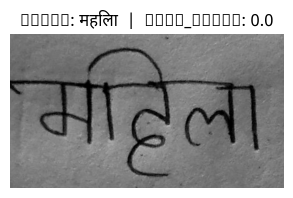

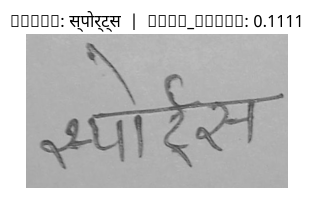

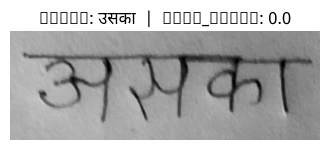

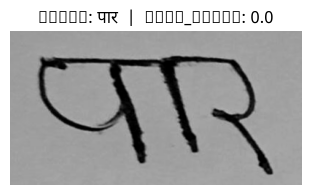

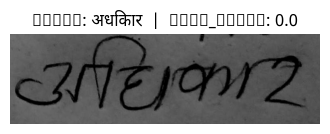

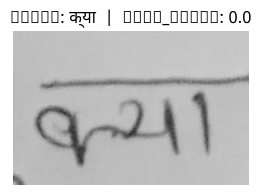

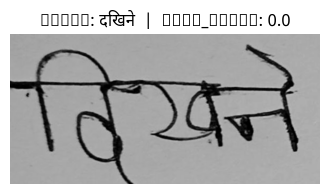

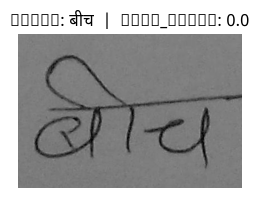

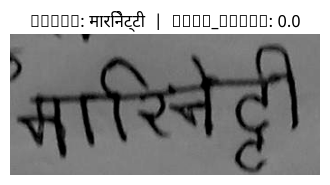

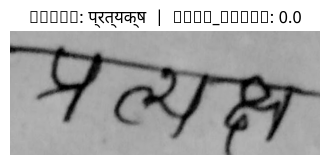

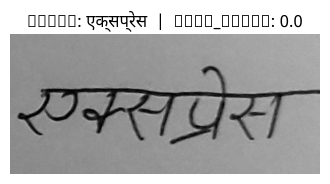

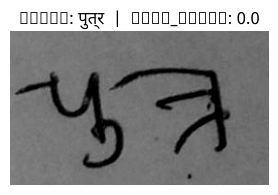

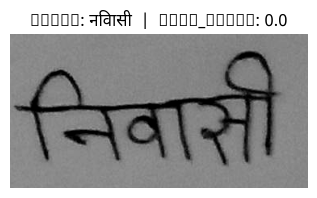

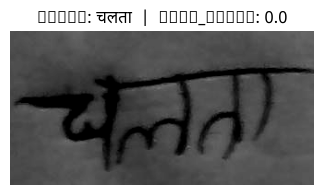

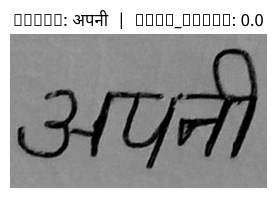

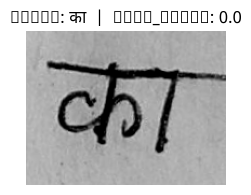

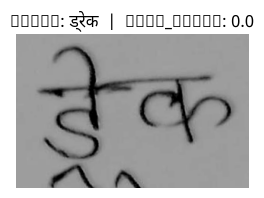

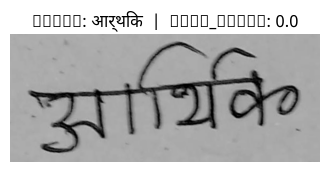

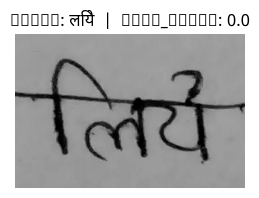

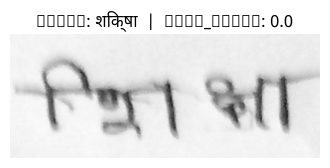

In [22]:
# ═══════════════════════════════════════════════════════
# CELL 13 — Spot-check pseudo-labels (Devanagari font enabled)
# ═══════════════════════════════════════════════════════
import matplotlib, matplotlib.font_manager as fm, urllib.request

font_url = "https://github.com/googlefonts/noto-fonts/raw/main/unhinted/ttf/NotoSansDevanagari/NotoSansDevanagari-Regular.ttf"
font_path = OUTPUT_DIR / "NotoSansDevanagari-Regular.ttf"
if not font_path.exists():
    urllib.request.urlretrieve(font_url, font_path)
fm.fontManager.addfont(str(font_path))
matplotlib.rcParams["font.family"] = fm.FontProperties(fname=str(font_path)).get_name()

sample = random.sample(balanced_pseudo, min(20, len(balanced_pseudo)))
for p in sample:
    fp = PSEUDO_CROP_DIR / p["crop_file"]
    if fp.exists():
        img = Image.open(fp).convert("RGB")
        plt.figure(figsize=(4,2))
        plt.imshow(img)
        plt.title(f"Label: {p['gt_text']}  |  edit_ratio: {p['edit_ratio']}")
        plt.axis("off")
        plt.show()

In [23]:
# ═══════════════════════════════════════════════════════
# CELL 14 — Isolated punctuation-recognition diagnostic
# (using GT-labeled akshar crops, bypasses YOLO entirely — this is
# what found the 49% punctuation-drop bug and confirmed it's an
# EOS/decoder-termination issue, not a detection issue)
# ═══════════════════════════════════════════════════════
punct_crops_diag = [p for p in gt_crop_paths if any(c in PUNCT_CHARS for c in p["text"])]
print(f"GT crops containing punctuation: {len(punct_crops_diag)} / {len(gt_crop_paths)}")

sample_diag = random.sample(punct_crops_diag, min(100, len(punct_crops_diag)))
pvs_diag = [preprocess_crop_for_trocr(Image.open(p["crop_path"]).convert("RGB")) for p in sample_diag]
preds_diag = recognize_batch(pvs_diag)

fully_correct, pure_punct_drop, word_also_wrong = 0, 0, 0
for p, pred in zip(sample_diag, preds_diag):
    gt_word_only = ''.join(c for c in p["text"] if c not in PUNCT_CHARS).strip()
    pred_word_only = ''.join(c for c in pred if c not in PUNCT_CHARS).strip()
    gt_punct = set(c for c in p["text"] if c in PUNCT_CHARS)
    pred_punct = set(c for c in pred if c in PUNCT_CHARS)
    word_ok = (gt_word_only == pred_word_only)
    punct_ok = gt_punct.issubset(pred_punct)
    if word_ok and punct_ok: fully_correct += 1
    elif word_ok and not punct_ok: pure_punct_drop += 1
    else: word_also_wrong += 1

print(f"\nBEFORE fine-tuning (this session's baseline):")
print(f"  Fully correct: {fully_correct}/{len(sample_diag)}")
print(f"  Pure punctuation drop: {pure_punct_drop}/{len(sample_diag)}")
print(f"  Word also wrong: {word_also_wrong}/{len(sample_diag)}")

GT crops containing punctuation: 821 / 8123

BEFORE fine-tuning (this session's baseline):
  Fully correct: 42/100
  Pure punctuation drop: 46/100
  Word also wrong: 12/100


In [26]:
# ═══════════════════════════════════════════════════════
# CELL 15 — Pipeline fine-tuning (recipe unchanged — it worked:
# punctuation-drop went 42→3 in your run). Fixes in this version:
#   1. EARLY_STOP_PAGES widened from 30→80 pages — a fixed 30-page
#      slice checked repeatedly risks indirectly overfitting
#      checkpoint-selection to that specific slice's quirks. A larger
#      fixed slice makes any single page's noise matter less.
#   2. tqdm added to the baseline WER computation (quick_pipeline_wer),
#      which previously ran silently with no progress feedback.
#   3. Baseline printed clearly as its own block before training starts.
#   4. Optional full-380-val baseline, OFF by default (informational
#      only, costs ~1.5-2hrs, not required — see note below).
# ═══════════════════════════════════════════════════════
import albumentations as A

# ── 1. Build the oversampled training mix ────────────────
pseudo_final = []
for p in balanced_pseudo:
    text = unicodedata.normalize("NFC", p["gt_text"])
    if all(c in char_to_token for c in text):
        pseudo_final.append({"crop_path": str(PSEUDO_CROP_DIR / p["crop_file"]), "text": text})

gt_crop_paths_punct = [p for p in gt_crop_paths if any(c in PUNCT_CHARS for c in p["text"])]
gt_crop_paths_no_punct = [p for p in gt_crop_paths if not any(c in PUNCT_CHARS for c in p["text"])]

PUNCT_OVERSAMPLE_FACTOR = 8
all_pairs = (yolo_pairs
             + gt_crop_paths_no_punct * 2
             + gt_crop_paths_punct * (2 * PUNCT_OVERSAMPLE_FACTOR)
             + pseudo_final)
random.seed(42); random.shuffle(all_pairs)

n_punct_examples = len(gt_crop_paths_punct) * 2 * PUNCT_OVERSAMPLE_FACTOR
print(f"Total training pairs: {len(all_pairs)}")
print(f"  YOLO-matched: {len(yolo_pairs)}")
print(f"  GT (no punct) x2: {len(gt_crop_paths_no_punct)*2}")
print(f"  GT (with punct) x{2*PUNCT_OVERSAMPLE_FACTOR}: {n_punct_examples} "
      f"({100*n_punct_examples/len(all_pairs):.1f}% of total mix)")
print(f"  Pseudo-labels: {len(pseudo_final)}")

# ── 2. Dataset ────────────────────────────────────────────
class LazyPairDataset(Dataset):
    def __init__(self, pairs, augment=False):
        self.pairs = pairs
        self.augment = augment
        if augment:
            self.aug = A.Compose([
                A.RandomBrightnessContrast(0.15, 0.15, p=0.35),
                A.GaussNoise(var_limit=(5, 25), p=0.25),
                A.Rotate(limit=1.5, border_mode=cv2.BORDER_CONSTANT, value=255, p=0.2),
            ])
    def __len__(self): return len(self.pairs)
    def __getitem__(self, idx):
        pair = self.pairs[idx]
        img = pair.get("crop")
        if img is None:
            img = Image.open(pair["crop_path"]).convert("RGB")
        text = pair["text"]
        if self.augment and hasattr(self, "aug"):
            arr = np.array(img)
            img = Image.fromarray(self.aug(image=arr)["image"])
        pv = preprocess_crop_for_trocr(img)
        token_ids = encode(text)[:MAX_LEN]
        token_ids += [PAD_ID] * (MAX_LEN - len(token_ids))
        labels = torch.tensor(token_ids, dtype=torch.long)
        di = labels.clone(); di = torch.roll(di, 1); di[0] = BOS_ID
        labels[labels == PAD_ID] = -100
        return pv, di, labels

BATCH_SIZE = 16
train_ds = LazyPairDataset(all_pairs, augment=True)
train_dl = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True,
                       num_workers=0, pin_memory=True, drop_last=True)
steps_per_epoch = len(train_dl)
print(f"\nSteps per epoch: {steps_per_epoch}")

# ── 3. Unfreeze: encoder frozen, last 3 decoder layers + embed/head ──
LAST_N_DECODER_LAYERS = 3
for p in model.parameters():
    p.requires_grad = False
decoder_layers = model.decoder.model.decoder.layers if hasattr(model.decoder, "model") \
                  else model.decoder.decoder.layers
n_layers = len(decoder_layers)
for i, layer in enumerate(decoder_layers):
    for p in layer.parameters():
        p.requires_grad = (i >= n_layers - LAST_N_DECODER_LAYERS)

try:
    for p in model.decoder.get_output_embeddings().parameters():
        p.requires_grad = True
except (AttributeError, NotImplementedError):
    for name, p in model.decoder.named_parameters():
        if "output_projection" in name or "lm_head" in name:
            p.requires_grad = True
try:
    model.decoder.get_input_embeddings().weight.requires_grad = True
except AttributeError:
    pass

trainable = sum(p.numel() for p in model.parameters() if p.requires_grad)
total = sum(p.numel() for p in model.parameters())
print(f"\nTrainable: {trainable:,} / {total:,} ({100*trainable/total:.2f}%) "
      f"— last {LAST_N_DECODER_LAYERS} of {n_layers} decoder layers + embed/head")

# ── 4. Optimizer — two LR groups ──────────────────────────
embed_weight = model.decoder.get_input_embeddings().weight
decoder_body_params = [p for n, p in model.named_parameters()
                        if p.requires_grad and p is not embed_weight
                        and "output_projection" not in n and "lm_head" not in n]
embed_head_params = [p for n, p in model.named_parameters()
                      if p.requires_grad and (p is embed_weight
                      or "output_projection" in n or "lm_head" in n)]
seen_ids = set()
embed_head_params_dedup = []
for p in embed_head_params:
    if id(p) not in seen_ids:
        embed_head_params_dedup.append(p); seen_ids.add(id(p))
decoder_body_params = [p for p in decoder_body_params if id(p) not in seen_ids]

opt = optim.AdamW([
    {"params": decoder_body_params, "lr": 2e-6, "weight_decay": 1e-4},
    {"params": embed_head_params_dedup, "lr": 1e-6, "weight_decay": 0.0},
])
try:
    scaler = GradScaler("cuda")
except TypeError:
    scaler = GradScaler()
loss_fn = nn.CrossEntropyLoss(ignore_index=-100)

# ── 5. WIDENED early-stop set (30→80 pages) — FIX #1 ─────
EARLY_STOP_PAGES = val_pages[50:130]   # 80 pages, still disjoint from
                                        # the reporting range (0-49)

def quick_pipeline_wer(pages, desc="WER check"):
    """FIX #2: tqdm added — 80-page checks are no longer instant,
    worth showing progress rather than a silent pause."""
    wers = []
    for pg in tqdm(pages, desc=desc, leave=False, unit="page"):
        gt = (pg.get("text") or "").strip()
        if not gt: continue
        pred = page_pipeline(pg)
        wers.append(compute_metrics_punctnorm(pred, gt)["wer"])
    return np.mean(wers) if wers else 1.0


# Baseline print 
baseline_wer_earlystop = np.mean(wers)   # ← from Cell 10 (already punct‑norm)
print(f"Baseline WER : {baseline_wer_earlystop:.4f}\n")

# ── 6. Training loop ───────────────────────────────────────
CKPT_PATH = OUTPUT_DIR / "trocr_base_pipeline_finetuned_v3.pt"
best_wer = baseline_wer_earlystop
MAX_EPOCHS = 8
CHECK_EVERY_STEPS = 1000
PATIENCE = 5   # 5 consecutive non‑improving quick checks → stop
bad_checks = 0
step = 0
saved_any = False

model.train(); model.encoder.eval()
print(f"Starting fine-tune. Max {MAX_EPOCHS} epochs, patience={PATIENCE} checks "
      f"({CHECK_EVERY_STEPS} steps each). Baseline to beat: {best_wer:.4f}\n")

stop_training = False
for ep in range(1, MAX_EPOCHS + 1):
    if stop_training:
        break
    t0 = time.time()
    pbar = tqdm(train_dl, desc=f"Epoch {ep}/{MAX_EPOCHS}", unit="batch")
    for pvs, di, labels in pbar:
        pvs = pvs.to(DEVICE); di = di.to(DEVICE); labels = labels.to(DEVICE)
        with autocast("cuda"):
            out = model(pixel_values=pvs, decoder_input_ids=di)
            loss = loss_fn(out.logits.reshape(-1, out.logits.size(-1)), labels.reshape(-1))
        scaler.scale(loss).backward()
        torch.nn.utils.clip_grad_norm_([p for p in model.parameters() if p.requires_grad], 1.0)
        scaler.step(opt); scaler.update(); opt.zero_grad()
        step += 1
        pbar.set_postfix(loss=f"{loss.item():.4f}")

        if step % CHECK_EVERY_STEPS == 0:
            model.eval()
            real_wer = quick_pipeline_wer(EARLY_STOP_PAGES, desc=f"Check @ step {step}")
            pbar.write(f"  step {step} (ep {ep}): train_loss={loss.item():.4f}  "
                       f"WER(80 pages, punct-norm)={real_wer:.4f}")
            if real_wer < best_wer:
                best_wer = real_wer
                torch.save({"model_state_dict": model.state_dict()}, CKPT_PATH)
                saved_any = True
                bad_checks = 0
                pbar.write(f"    -> new best, saved")
            else:
                bad_checks += 1
                pbar.write(f"    -> no improvement ({bad_checks}/{PATIENCE})")
                if bad_checks >= PATIENCE:
                    pbar.write(f"    Early stopping triggered at step {step}.")
                    stop_training = True
                    break
            model.train(); model.encoder.eval()
    print(f"Epoch {ep} done in {time.time()-t0:.0f}s")

print(f"\nTraining complete. Best WER: {best_wer:.4f}  Improved: {saved_any}")

# ── 7. Load best checkpoint, re-verify punctuation fix ────
if saved_any:
    ck = torch.load(CKPT_PATH, map_location="cpu", weights_only=False)
    model.load_state_dict(ck["model_state_dict"])
    print("Loaded best fine-tuned checkpoint.\n")
else:
    print("No improvement found — keeping the pre-fine-tune checkpoint.\n")
model = model.to(DEVICE).eval()

print("── Post-training punctuation-retention check ──")
sample_check = random.sample(punct_crops_diag, min(100, len(punct_crops_diag)))
pvs_check = [preprocess_crop_for_trocr(Image.open(p["crop_path"]).convert("RGB")) for p in sample_check]
preds_check = recognize_batch(pvs_check)

fully_correct2, pure_punct_drop2, word_also_wrong2 = 0, 0, 0
for p, pred in zip(sample_check, preds_check):
    gt_word_only = ''.join(c for c in p["text"] if c not in PUNCT_CHARS).strip()
    pred_word_only = ''.join(c for c in pred if c not in PUNCT_CHARS).strip()
    gt_punct = set(c for c in p["text"] if c in PUNCT_CHARS)
    pred_punct = set(c for c in pred if c in PUNCT_CHARS)
    word_ok = (gt_word_only == pred_word_only)
    punct_ok = gt_punct.issubset(pred_punct)
    if word_ok and punct_ok: fully_correct2 += 1
    elif word_ok and not punct_ok: pure_punct_drop2 += 1
    else: word_also_wrong2 += 1

print(f"AFTER fine-tuning: Fully correct: {fully_correct2}/100  "
      f"Pure punct drop: {pure_punct_drop2}/100  Word also wrong: {word_also_wrong2}/100")
print(f"(Before fine-tuning, from Cell 14: {fully_correct}/{pure_punct_drop}/{word_also_wrong})")

Total training pairs: 91737
  YOLO-matched: 7103
  GT (no punct) x2: 14604
  GT (with punct) x16: 13136 (14.3% of total mix)
  Pseudo-labels: 56894

Steps per epoch: 5733

Trainable: 48,960,512 / 282,593,792 (17.33%) — last 3 of 12 decoder layers + embed/head
Baseline WER : 0.3439

Starting fine-tune. Max 8 epochs, patience=5 checks (1000 steps each). Baseline to beat: 0.3439



Epoch 1/8:   0%|          | 0/5733 [00:00<?, ?batch/s]

Check @ step 1000:   0%|          | 0/80 [00:00<?, ?page/s]

  step 1000 (ep 1): train_loss=0.0904  WER(80 pages, punct-norm)=0.3286
    -> new best, saved


Check @ step 2000:   0%|          | 0/80 [00:00<?, ?page/s]

...

Check @ step 17000:   0%|          | 0/80 [00:00<?, ?page/s]

  step 17000 (ep 3): train_loss=0.1047  WER(80 pages, punct-norm)=0.3030
    -> new best, saved
Epoch 3 done in 11420s


Epoch 4/8:   0%|          | 0/5733 [00:00<?, ?batch/s]

Check @ step 18000:   0%|          | 0/80 [00:00<?, ?page/s]

KeyboardInterrupt: 

In [ ]:
# ═══════════════════════════════════════════════════════
# CELL 16 (REVISED) — Load the TRUE held-out test set and evaluate
# on it. val_pages has been used repeatedly for scoring decisions,
# early-stop checkpointing comparisons, and diagnostics throughout
# this project — it's no longer a clean estimate of real performance.
# line_test.parquet has never been touched by any decision so far.
# ═══════════════════════════════════════════════════════
LINE_TEST_PATH = Path("/kaggle/input/datasets/nehamalik10/hindi-page-level-dataset/line_test.parquet")
assert LINE_TEST_PATH.exists(), f"Not found: {LINE_TEST_PATH}"

test_df = pd.read_parquet(LINE_TEST_PATH)
test_pages = [{"image_bytes": row["image_bytes"], "text": row["text"]} for _, row in test_df.iterrows()]
print(f"Loaded {len(test_pages)} TRUE held-out test pages")

def inject_terminal_danda(lines):
    terminal = set('।॥.!?')
    out = []
    for line in lines:
        line = line.strip()
        if line and line[-1] not in terminal:
            line = line + ' ।'
        out.append(line)
    return out

def page_pipeline_final(page):
    raw = page_pipeline(page)
    lines = inject_terminal_danda(raw.split("\n"))
    return "\n".join(lines)

N_TEST_EVAL = len(test_pages)   # full 380 — this is the real number, worth the time
cers_raw, wers_raw = [], []
cers_norm, wers_norm = [], []

pbar = tqdm(range(N_TEST_EVAL), desc="TRUE test eval", unit="page")
for i in pbar:
    gt = (test_pages[i].get("text") or "").strip()
    if not gt: continue
    pred = page_pipeline_final(test_pages[i])

    m_raw = compute_metrics(pred, gt)
    m_norm = compute_metrics_punctnorm(pred, gt)
    cers_raw.append(m_raw["cer"]); wers_raw.append(m_raw["wer"])
    cers_norm.append(m_norm["cer"]); wers_norm.append(m_norm["wer"])
    pbar.set_postfix(raw_WER=f"{np.mean(wers_raw):.3f}", norm_WER=f"{np.mean(wers_norm):.3f}")

print(f"\n{'='*70}")
print(f"TRUE HELD-OUT TEST SET ({len(cers_norm)} pages, never touched before now)")
print(f"{'='*70}")
print(f"RAW scoring (reference only):        CER={np.mean(cers_raw):.4f}  WER={np.mean(wers_raw):.4f}  "
      f"WordAcc={(1-np.mean(wers_raw))*100:.1f}%")
print(f"OFFICIAL scoring (punct-normalized): CER={np.mean(cers_norm):.4f}  WER={np.mean(wers_norm):.4f}  "
      f"WordAcc={(1-np.mean(wers_norm))*100:.1f}%")
print(f"{'='*70}")